<h1 style="text-align: center;">Stock Market: Analyzing some stock market trends and statistics</h1>


<h2>1 Background and objectives</h2><h3>1.1 Introduction</h3><p>The stock market and the activities or agents related to it have drawn the fascination of the general public for decades. The most clear evidence of this is that news articles, books and even films have been produced to either praise or criticize the nature of the stock market. Typically, the stock market is a marketplace to trade some kind of good or service, in this case a financial asset. More precisely, participants in the stock market buy and sell securities like shares of a company, bonds or even more complex assets.<p>This project focus in the tools that economic agents may utilize in order to make informed decisions on how to approach investing in stocks and ultimately, make profits on it.</p

<h3>1.2 Objectives</h3><p>The objectives of this project are: </p><ul><li>Take a dataset which represents stock information and modify data that can be improved</li><li>Reorginaze data so that information about each stock market sector is defined</li><li>Calculate the mean of the price, revenue and net income of companies in the stock market</li><li>Find out the countries with the most companies listed as the top companies</li></ul>

<h3>1.3 Data</h3><h4>1.3.1 Choice of dataset</h4><p>The main (and first ) dataset chosen to work with is in <a href="https://www.financecharts.com/screener/biggest">https://www.financecharts.com/screener/biggest</a> , we will call it "stock dataset". This dataset is available to download in xlsx format and I have chosen to work with that file format stored in disk, therefore, the file is stored inside the project folder (zip submition) specifically inside folder "/Data". The source of the above mentioned dataset is FinanceCharts.com, which is an independent website that provides information for investors on different financial metrics. The data source shows the 200 most important companies in the stock market and some relevant information about them, like stock price, revenue, net income, market cap, etc.</p><p>The other data source is in <a href="https://www.nationsonline.org/oneworld/country_code_list.htm">https://www.nationsonline.org/oneworld/country_code_list.htm</a> and we will call it "country dataset" , a page that matches country codes for each country name. This page will be utilized to clean and modify some data in the "stock dataset". In this case, the webpage does not provide with a downloadable version of the HTML, therefore, webscraping will be essential to pull out data.</p>

<h4>1.3.2 Limitations of the data</h4><p>The "stock dataset" provides usefull information about the current state of the stock market, however, it is just a picture of the present. Investors usually need information about the past for the present may be the culmination of trends that take place in the near past. In other words, this dataset is not ideal in the sense of providing complete insights on what stocks will be more profitable for investors.</p>

<h3>Ethical considerations</h3><p>The "stock dataset" is in a webpage that provides information for free. Furthermore, its author has explained that the purpose of the webpage is to deliver financial metrics in a straightforward way, so that novice or non-experts can start their journey of the financial markets. Any person can confidently state that the information provided by the dataset is not biased because information about the stock market is utterly public and non-secretive, for the regulatory agencies impose transparency on all parties involved.</p><p>The "country dataset" does not have a clause forbidding webscraping in their terms and condition. The website clearly states that its intention is to provide information to the general public.</p>
<p>The analysis and conclusions of this project have to be taken cautiosly, consider the following:</p><ul><li>The data used in this project focus in basic metrics like revenue or net income. Further analysis of the markets would require more sophisticated tools like free cash flow or debt-to-equity ratio.</li><li>From the previous point, we can deduce that the conclusions of this project should not be taken as investing advice or recommendation.</li></ul>

<h2>2 Imports</h2><p>The libraries needed are pandas, numpy, matplotlib and bs4</p>
<p>Additonally, the selenium library is used (which is not taught in this module) because
webscrapping will be performed on a webpage that is generated using Javascript.</p><p>*To download selenium library in anaconda, type in the anaconda prompt: "conda install -c conda-forge selenium"</p><p>It is appropiate to import the class 'FuncFormatter' from matplotlib, because it will be useful to format the y label or ticks of the plots (charts)</p>

In [1]:
#Import necessary libraries and modules
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

#Import selenium to handle webpages generated with JS
from selenium import webdriver
from selenium.webdriver import Chrome
from selenium.webdriver.common.by import By

<h2>3 Dataset to pandas</h2><p>Here we use pandas to read a xlsx file stored in the folder '/Data', and use it to create a new DataFrame object called 'base_data'. This file is downloaded from the
    webpage <a href="https://www.financecharts.com/screener/biggest">https://www.financecharts.com/screener/biggest</a></p>

In [2]:
base_data = pd.read_excel("Data/BiggestCompanies2024.xlsx", usecols="A:L", skiprows=[1], nrows=202)

<p>Notice the unsusual high value in the column "Close Price". To avoid tampering the analysis and statistics derived from the dataset, the row with the unsusual high value (616670) is deleted. Also notice that the dataset is order by market capitalization of each company, from highsest ot lowest.</p>

In [3]:
base_data["Close Price"].describe()

count       200.000000
mean       3317.549320
std       43590.581793
min           0.614000
25%          48.175000
50%         111.050000
75%         245.787500
max      616670.000000
Name: Close Price, dtype: float64

In [4]:
#Delete the row with the unsusual value of 616670
base_data.drop(base_data.loc[base_data["Close Price"]==616670].index, inplace=True)
base_data.reset_index(drop=True, inplace=True)
#Notice there is only 1 Berkshire Hathaway entry in this partial dataset from 'base_data'
base_data[5:10]

,Name,Ticker,Country,Sector,Market Cap,Close Price,Price Change,TTM Revenue,TTM Net Income,TTM Total Rtn,3Y Total Rtn,Div Yield
5,Saudi Aramco,2222.SR,SA,Energy,2.119379e+12,32.85,-0.152,5.024495e+11,1.206079e+11,18.898,27.288,5.545
6,Amazon.com Inc,AMZN,US,Consumer Discretionary,1.983534e+12,189.08,1.601,5.907400e+11,3.768400e+10,51.470,9.486,0.000
7,Meta Platforms Inc,META,US,Communication Services,1.238116e+12,494.78,-1.379,1.427110e+11,4.575700e+10,76.039,49.206,0.202
8,Berkshire Hathaway Inc,BRK.B,US,Financials,8.832579e+11,409.62,0.115,3.689580e+11,7.342100e+10,20.971,47.824,0.000
9,Eli Lilly and Co,LLY,US,Health Care,8.388212e+11,883.88,-0.238,3.593210e+10,6.138400e+09,96.574,310.391,0.588


<h2>4 Webscraping</h2>

<h3>4.1 Defining scraping function</h3><p>The file 'BiggestCompanies2024.xlsx' is read into a pandas DataFrame called 'base_data'; 
however, the column 'Country' stores just the alpha 2 country code of each company. This is not ideal as the data analysis
implemented in this project will take in consideration the country of each company, thus it is more suitable to have the country name explicitly declared. To address this problem, a webpage that matches country codes with country names will be webscraped.</p>
<p>The webpage to be scraped is <a href=https://www.nationsonline.org/oneworld/country_code_list.htm>https://www.nationsonline.org/oneworld/country_code_list.htm</a>, 
it contains the name of the country and its respective code (alpha 2 code)</p><p>Instead of using the 'requests' library
(as taught in the module), the library used for webscraping is 'selenium' library. The reason for this decision lies in the fact that the target webpage to be webscraped load its content using Javascript, which makes 'requests' library unfitted for the task. Nontheless, selenium library can manage Javascript generated webpages.</p>
<p>The following function returns the content of a parsed webpage</p>

In [5]:
#This code assumes you are opening the webpage with Chrome browser.
#This function uses selenium library
def getParsedWebpage(URL):
    #Create a WebDriver object called 'driver' using selenium
    driver = Chrome()
    #Use the get() method of WebDriver object
    driver.get(URL)
    #Find "td" elements and accept all cookies
    country_names_codes = driver.find_elements(By.TAG_NAME, "//td[text()='Accept All']")
    
    #Select elements to be accesed
    for data in country_names_codes[1:]:
        data.click()
    soup = BeautifulSoup(driver.page_source, "html.parser")
    return soup

<h3>4.2 Extracting information</h3><p>Now we need to pass the webpage mentioned above (to be webscraped) to the getParsedWebpage() function. This will return the html tag structure of the page, which will be stored in the variable 'soup'</p><p>Then a loop through all td tags of 'soup' is performed. Going tag by tag, extraction of only the tags that contain "class" attribute equal to "abs" and no attribute 'colspan' is executed, which are the tags that contain either country names or country code. The adequate text of each tag is stored in either 'countries' or 'codes' list</p>
<p>Code below will store the country names in the list 'countries', and the country codes in the list 'codes'.</p>

In [6]:
soup = getParsedWebpage("https://www.nationsonline.org/oneworld/country_code_list.htm")

#List that stores the country names
countries = []
#List that stores the country codes (alpha 2 codes)
codes  = []

#Loop through all the relevant "td" tags and append them to the list 'countries'
#or the list 'codes'
for entry in soup.find_all("td"):
    if ("class" in entry.attrs) and ("colspan" not in entry.attrs):
        if "abs" in entry.attrs["class"]:
            if "a" in list(entry.descendants):
                elem1 = entry.find("a")
                countries.append(elem1)
                
                elem2 = entry.find_next("td")
                codes.append(elem2.text)
            elif "em" in list(entry.descendants):
                elem1 = entry.find("em")
                countries.append(elem1)
                
                elem2 = entry.find_next("td")
                codes.append(elem2.text)
            else:
                countries.append(entry.contents[0])
                
                elem2 = entry.find_next("td")
                codes.append(elem2.text)

#Extract only the text (content) of the "td" tag and update the list 'countries'
for i in range(len(countries)):
    countries[i] = countries[i].text.strip()


<h2>5 Data processing and cleaning</h2>

<h3>5.1 Storing extracted information and modifying the original DataFrame</h3>

<p>Use the lists 'countries' and 'codes' to create a new DataFrame called 'country_table'. This new object will match countries with its respective
country code. This new step of creating a new dataframe is suitable for our goal of updating the 'base_data' dataframe by using 'country_table' as a 'mapping' tool (mapping country codes to country names)</p>

In [7]:
#Create Dataframe of countries with their respective codes using the lists 'countries' and 'codes'
country_table = pd.DataFrame({"Country": countries, "Code": codes})
country_table.set_index("Code", inplace=True)

<p>This code updates the 'Country' column of the original dataframe ('base_data') with the precise country name</p>

In [8]:
#The column 'Country' of the DataFrame 'base_data' is updated using the 'country_table' dataframe
for i in range(len(base_data)):
    base_data.at[i, "Country"] = country_table.at[base_data.at[i, "Country"], "Country"]

<h2>6 New dataframes for data analysis</h2>

<p>For analyzing data, new dataframes will be needed so that data is easier to represent and analyze. Moreover, plotting will be far more straightforward. Additionally, saturating the initial steps of the data pipeline is avoided.</p>

<h3>6.1 New dataframe: Mean stats by sector</h3><p>It would be interesting to analyze data based on the different stock market sectors, rather that looking at all of the individual companies. In particular, the stock price mean, the revenue mean and the net income mean for each of the individual market sectors (e.g Information Technology, Communication Services, Energy, etc.) will be stored in a dataframe.</p><p>The code below creates a Series object that stores all the stock market sectors and deletes duplicates.</p>

In [9]:
#The stock market sectors are extracted from the initial dataframe ("base_data"), and stored in
#new Series variable called 'sectors'
sectors = pd.Series(base_data["Sector"].drop_duplicates(ignore_index=True))
sectors

0     Information Technology
1     Communication Services
2                     Energy
3     Consumer Discretionary
4                 Financials
5                Health Care
6           Consumer Staples
7                  Materials
8                Industrials
9                  Utilities
10               Real Estate
Name: Sector, dtype: object

<p>The following code builds the new dataframe that stores mean values for different stock market sectors.</p>

In [10]:
#This three lists will be used to build three new Series objects
price_list = []
revenue_list = []
net_income_list = []

#Iterate through all the market sectors (from the variable 'sectors')
for sector in sectors:
    #Calculate the mean stock price for the corresponding market sector and store it in the corresponding list
    price_list.append(base_data[base_data["Sector"]==sector]["Close Price"].mean())
    #Create a new Series object from the 'price_list'
    price_series = pd.Series(price_list)
    
     #Calculate the mean revenue for the corresponding market sector and store it in the corresponding list
    revenue_list.append(base_data[base_data["Sector"]==sector]["TTM Revenue"].mean())
    #Create a new Series object from the 'revenue_list'
    revenue_series = pd.Series(revenue_list)
    
     #Calculate the mean net income for the corresponding market sector and store it in the corresponding list
    net_income_list.append(base_data[base_data["Sector"]==sector]["TTM Net Income"].mean())
    #Create a new Series object from the 'net_income_list'
    net_income_series = pd.Series(net_income_list)

#This dictionary use the above new Series objects. Then it will be used to create a new dataframe
dict_averages = {"Sector": sectors,"Stock Price": price_series, "Revenue": revenue_series, "Net Income": net_income_series}

#Dataframe of mean stats by sector
means_by_sector = pd.DataFrame(dict_averages)

means_by_sector

,Sector,Stock Price,Revenue,Net Income
0,Information Technology,342.522324,5.468210e+10,1.082212e+10
1,Communication Services,168.455833,1.338580e+11,2.394791e+10
2,Energy,47.238538,2.085043e+11,2.385624e+10
3,Consumer Discretionary,413.650880,8.135761e+10,8.448485e+09
4,Financials,147.652943,1.011338e+11,1.674257e+10
5,Health Care,267.057143,6.312279e+10,6.600518e+09
6,Consumer Staples,149.822167,1.236041e+11,8.787822e+09
7,Materials,132.096667,4.327480e+10,8.032548e+09
8,Industrials,203.639852,4.037831e+10,3.808158e+09
9,Utilities,75.635000,2.627450e+10,5.868000e+09


<h2>7 Plotting</h2><h3>7.1 Plot: Mean values by sector</h3>

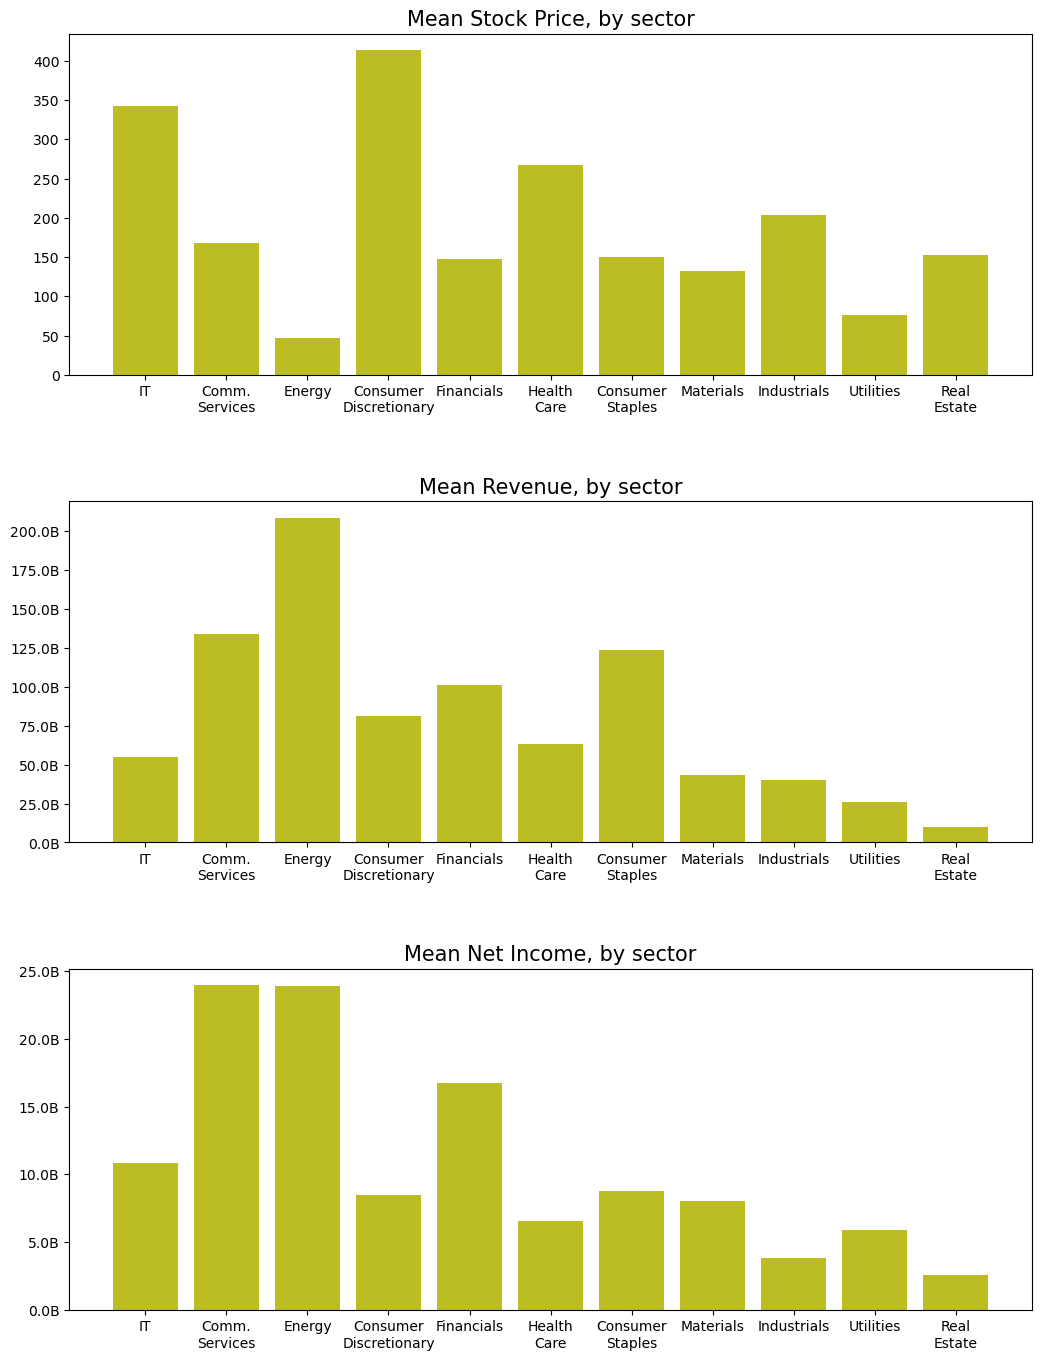

In [11]:
#This functions is used to format the y label of the charts (in billions)
def billions(x, pos):
    return '%1.1fB' % (x * 1e-9)

#FuncFormatter object (from matplotlib library)
formatter = FuncFormatter(billions)

#Add a new line to long labels
x_labels = []
for s in means_by_sector["Sector"]:
    if s == "Information Technology":
        x_labels.append("IT")
    elif s == "Communication Services":
        x_labels.append("Comm.\nServices")
    else:
        x_labels.append(s.replace(" ", "\n"))

#Draw stock price chart
fig, axes = plt.subplots(3, 1, figsize=[12, 15])
fig.tight_layout(pad=7.0)
axes[0].bar(x_labels, height=means_by_sector["Stock Price"], color='tab:olive')
axes[0].set_title('Mean Stock Price, by sector', size=(15))

#Draw revenue chart
axes[1].yaxis.set_major_formatter(formatter) #Format y label
axes[1].bar(x_labels, height=means_by_sector["Revenue"], color='tab:olive')
axes[1].set_title('Mean Revenue, by sector', size=(15))

#Draw net income chart
axes[2].yaxis.set_major_formatter(formatter) #Format y label
axes[2].bar(x_labels, height=means_by_sector["Net Income"], color='tab:olive')
axes[2].set_title('Mean Net Income, by sector', size=(15))

plt.show()


<h3>7.2 Plot: number of companies, by country</h3><p>In this part of the project, the goal is to indentify the countries which have more number of companies in the top 200 companies in the stock market.</p><p>The following plot only takes in consideration countries with 4 or more companies.</p>

In [12]:
#Create a pandas Series object calles 'country_freq'
country_freq = base_data["Country"].value_counts()
#Only consider countries with 4 or more companies
country_freq = country_freq[country_freq >= 4]

<Axes: title={'center': 'Number of companies, by Country'}, xlabel='Country'>

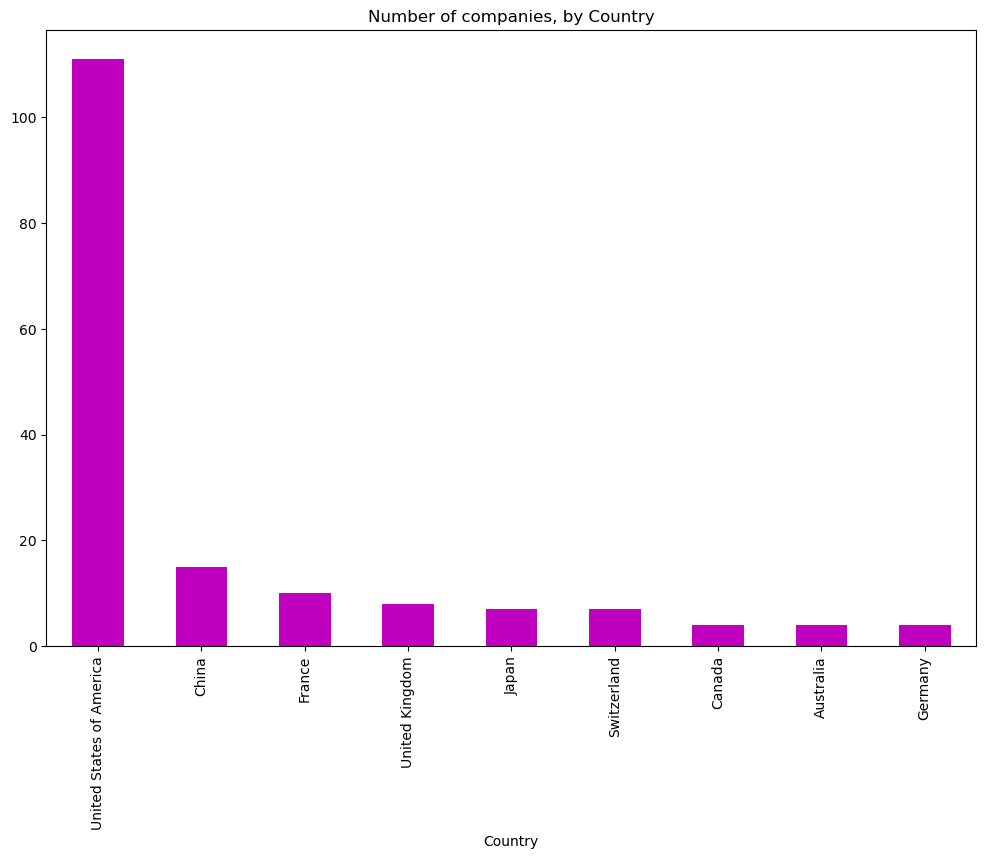

In [13]:
#Plot
country_freq.plot(kind="bar", figsize=(12,8), title="Number of companies, by Country", color="m")

<h2>8 Conclusions</h2><p>From the data analysis performed the chosen data set, some initial conclusions can be identified: <ul><li>The stock price  of companies in the Information technology sector or the Consumer discretionary sector are on average higher than the rest of the economy.</li><li>Energy companies on average have a noticeable higher revenue than the rest of the market sectors.</li><li>On average, Communication services and Energy companies are more profitable than the rest of the market sectors.</li><li>The United States is by far the country with the most number of top companies in the stock market.</li></ul></p>

<h2>9 References and resources</h2><h3>9.1 References</h3><p>[1] P.Gratton; "What Is the Stock Market and How Does It Work?". Available: <a href="https://www.investopedia.com/terms/s/stockmarket.asp">https://www.investopedia.com/terms/s/stockmarket.asp</a><br>
[2] javatpoint.com; "Selenium Python Tutorial". Available: <a href="https://www.javatpoint.com/selenium-python">https://www.javatpoint.com/selenium-python</a><br>
    [3] Pandas; "User Guide". Available: <a href="https://pandas.pydata.org/docs/user_guide/index.html">https://pandas.pydata.org/docs/user_guide/index.html</a></p>

<h3>9.2 Resources</h3><ul><li>Webscraping lecture and lab, Dr Sean McGrath</li><li>Codecademy Team; "Web Scrape with Selenium and Beautiful Soup". Available: <a href="https://www.codecademy.com/article/web-scrape-with-selenium-and-beautiful-soup">https://www.codecademy.com/article/web-scrape-with-selenium-and-beautiful-soup</a></li><li>GeeksforGeeks; "Matplotlib.ticker.FuncFormatter class in Python". Available: <a href="https://www.geeksforgeeks.org/matplotlib-ticker-funcformatter-class-in-python/">https://www.geeksforgeeks.org/matplotlib-ticker-funcformatter-class-in-python/</a></li></ul>